In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

In [ ]:


df = pd.read_csv("IRIS (1).csv")

# Display first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:


df.info()

In [ ]:


df.isnull().sum()

In [ ]:


df.duplicated().sum()

In [ ]:


df = df.drop_duplicates()

In [ ]:


if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:


encoder = LabelEncoder()

df['species'] = encoder.fit_transform(df['species'])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:


X = df.drop('species', axis=1)

y = df['species']

In [ ]:


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:


model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [ ]:


model.fit(X_train, y_train)

In [ ]:


y_pred = model.predict(X_test)

y_pred

In [ ]:


accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


In [ ]:


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:


cv_scores = cross_val_score(
    model,
    X_scaled,
    y,
    cv=5
)

print("Cross Validation Scores:", cv_scores)

print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.96666667 0.96666667 0.93103448 0.86206897 1.        ]
Average CV Score: 0.9452873563218391


## Conclusion

The Iris Flower Classification model was successfully developed to classify Iris flower species based on sepal and petal measurements. Data preprocessing techniques such as duplicate removal, label encoding, and feature scaling were applied to improve data quality and model performance.

A Random Forest Classifier was used for classification, and the model achieved an accuracy of approximately 96.67%, indicating excellent predictive performance. Cross-validation was also performed to evaluate model stability, resulting in an average cross-validation score of approximately 94.53%, which confirms that the model generalizes well to unseen data and shows minimal overfitting.

The confusion matrix and visualizations demonstrated that the model accurately distinguished between Iris Setosa, Iris Versicolor, and Iris Virginica species. Overall, this project highlights the complete machine learning workflow, including data preprocessing, visualization, model training, evaluation, and performance validation using a well-known multiclass classification dataset.


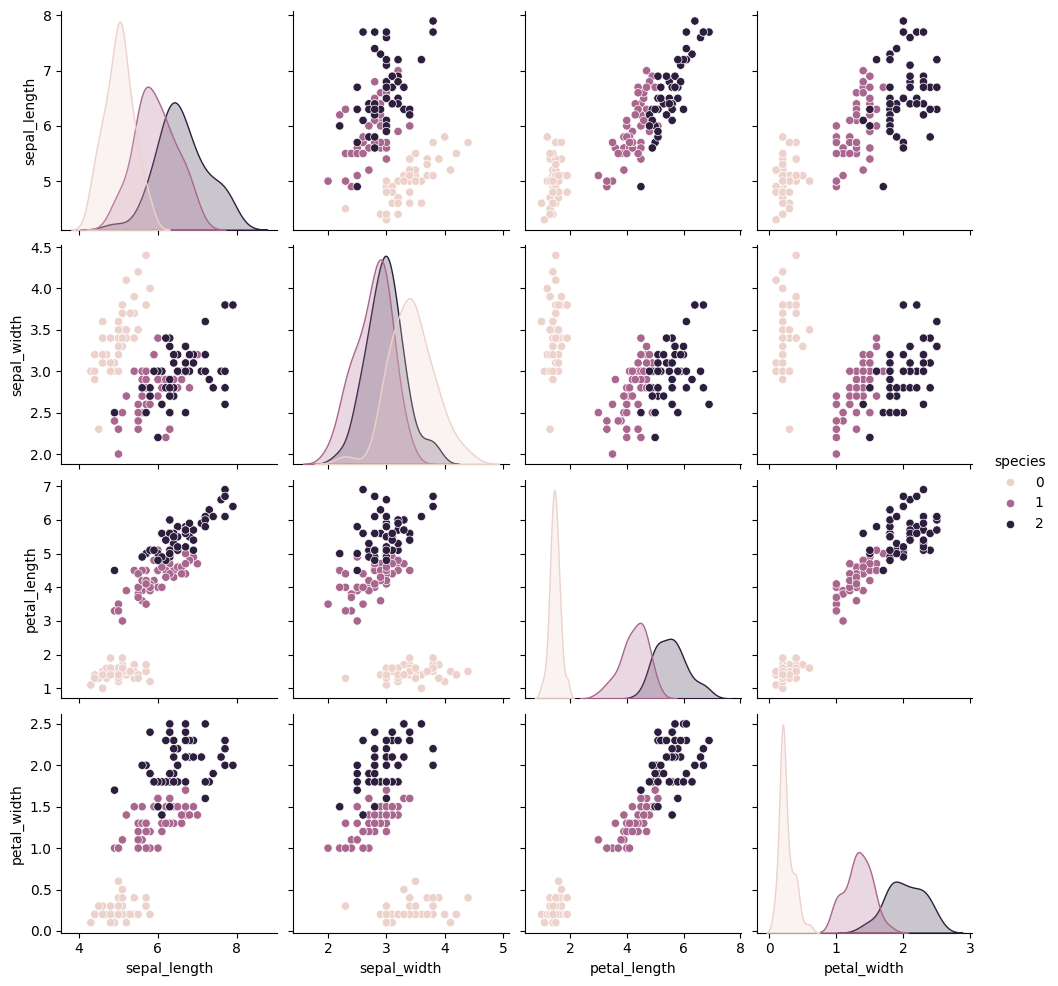

In [22]:
# Pairplot Visualization

sns.pairplot(df, hue='species')
plt.show()

### Observation:

The pairplot visualization shows that the three Iris flower species can be classified based on their sepal and petal measurements. Iris Setosa is clearly separated from the other species, while Iris Versicolor and Iris Virginica show slight overlap in some features. Petal length and petal width provide better distinction among the species compared to sepal measurements.


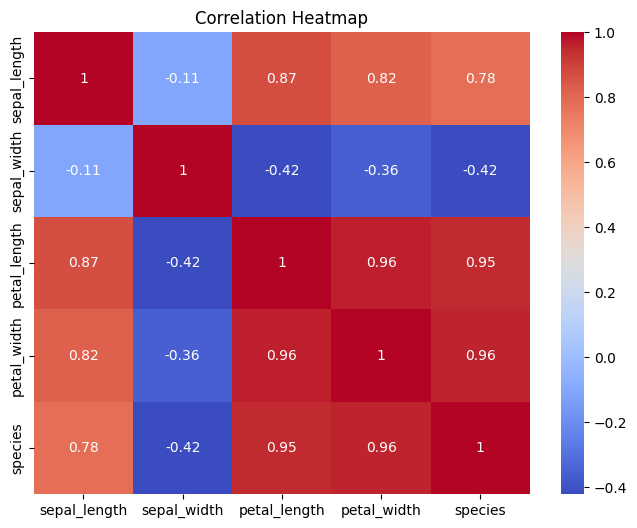

In [23]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Observation:

The correlation heatmap shows the relationship between the numerical features in the Iris dataset. Petal length and petal width have a strong positive correlation, indicating that both features increase together. Sepal measurements show comparatively weaker correlations. The heatmap helps identify important features that contribute to accurate classification of Iris flower species.


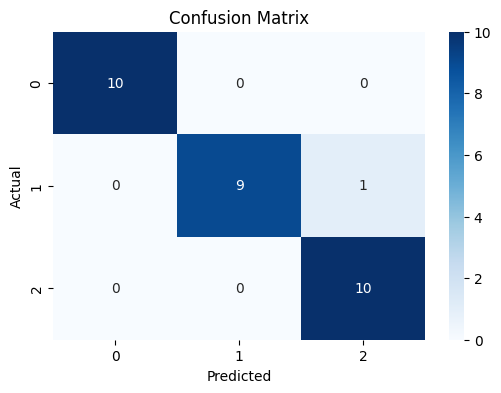

In [24]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Observation:

The confusion matrix shows that the Random Forest model classified most of the Iris flower samples correctly. The diagonal values represent correct predictions, while very few or no misclassifications are observed in the off-diagonal values. This indicates that the model achieved high accuracy and performed well in distinguishing between the three Iris species.


C:\Users\DELL\AppData\Local\Temp\ipykernel_11400\3516724126.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


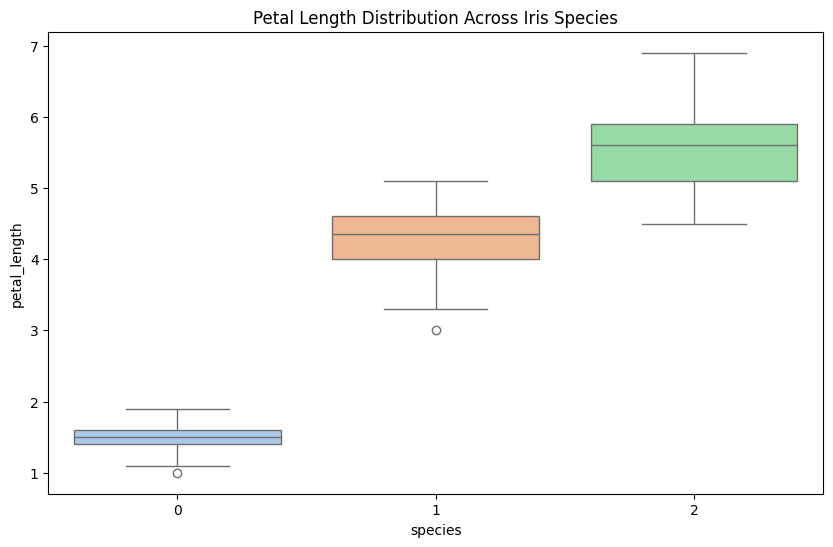

In [28]:
# Beautiful Boxplot Visualization

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    palette='pastel'
)

plt.title("Petal Length Distribution Across Iris Species")

plt.show()

### Observation:

The boxplot visualization shows the distribution of petal length values for each Iris species. Iris Setosa has the smallest petal lengths with very little variation, while Iris Virginica has the largest petal lengths. Iris Versicolor lies between the two species. This visualization indicates that petal length is an important feature for distinguishing among the different Iris flower species.


## Visualization Insight

The visualizations provide a clear understanding of the relationships and distribution of features in the Iris Flower Dataset. The pairplot demonstrates that petal measurements are highly effective in distinguishing between the three Iris species, especially Iris Setosa, which appears clearly separated from the others. The correlation heatmap reveals a strong positive relationship between petal length and petal width, indicating that these features are closely related and important for classification. The boxplot further highlights the variation in petal length across species, showing distinct feature distributions among Setosa, Versicolor, and Virginica. Overall, the visualizations confirm that petal-related features play a major role in accurately classifying Iris flower species and support the high performance achieved by the machine learning model.
